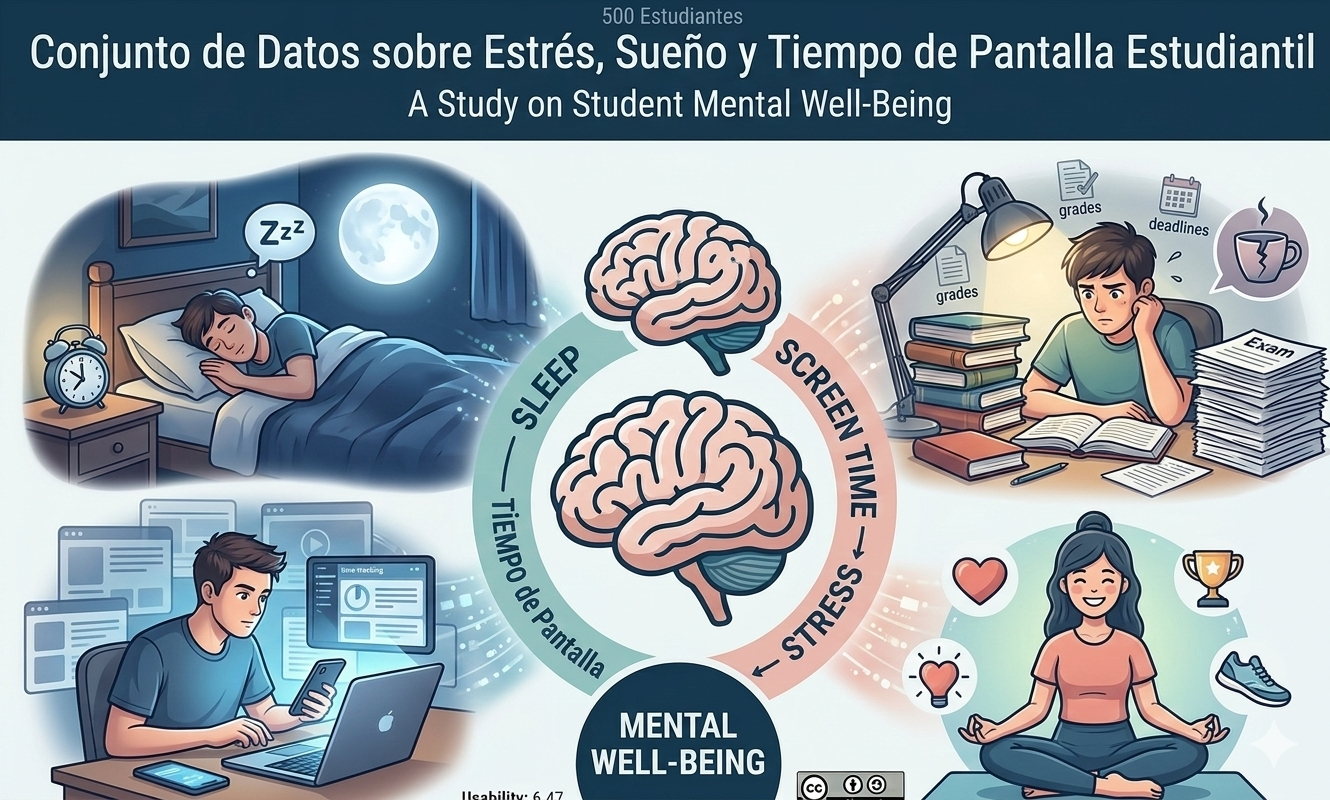

# **Student Stress, Sleep & Screen Time**


`Estudiantes: Santiago Sepulveda Blanco, Vivian Yulitza Ramirez, Carlos David Herrera.`

`Curso: Aprendizaje de Maquina.`

---

Este dataset contiene información sobre 500 estudiantes, analizando factores relacionados con hábitos de estudio, salud, estilo de vida y presión académica.

Las variables incluyen características demográficas, hábitos de estudio, uso de tecnología, descanso, actividad física y niveles de estrés.

---
### Variables númericas
---
* **Age** -> Edad del estudiante (18-25 años)
* **sleep_hours** -> Cantidad de horas de sueño por noches (4-9 horas)
* **screem_time_hours** -> Tiempo diario frente a la pantalla (2-12 horas)
* **study_hours** -> Horas de estudio al dia (2-8 horas)
* **coffeine_intake** -> consumo diario de cafeína (0-4 unidades)

---
### Variables categóricas
---
* **student_id** -> Identificador único del estudiante
* **gender** -> Género del estudiante
* **stress_level** -> Nivel de estrés del estudiante
* **physical_activity** -> Indica si el estudiante realiza actividad fisica
* **academic_pressure** -> Nivel de presión académica

---
### Importamos las librerias
---

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import scipy.stats as stats
import seaborn as sns
sns.set_theme()
from sklearn.model_selection import KFold
from sklearn.metrics import *

np.random.seed(21)

---
# Informacion del dataset
---


In [ ]:
df = pd.read_csv('https://drive.google.com/uc?id=1X4gLTWx5OwuxfhfyrYMz1-4VqP8IODri')

In [ ]:
df.head()

,student_id,age,gender,sleep_hours,screen_time_hours,stress_level,study_hours,physical_activity,caffeine_intake,academic_pressure
0,S001,22,Female,5.9,2.7,Medium,7.4,Yes,3,High
1,S002,25,Male,5.9,7.6,High,4.6,No,2,Low
2,S003,23,Male,8.0,3.2,Low,2.0,Yes,3,High
3,S004,22,Female,7.8,11.4,Medium,4.4,Yes,3,High
4,S005,20,Other,6.0,2.9,Medium,6.7,No,0,High


In [ ]:
df.describe()

,age,sleep_hours,screen_time_hours,study_hours,caffeine_intake
count,500.000000,500.000000,500.000000,500.000000,500.00000
mean,21.532000,6.547200,7.109600,5.019000,1.98000
std,2.244784,1.436098,2.906366,1.759856,1.39409
min,18.000000,4.000000,2.000000,2.000000,0.00000
25%,20.000000,5.300000,4.575000,3.500000,1.00000
50%,22.000000,6.500000,7.300000,5.000000,2.00000
75%,23.000000,7.800000,9.500000,6.600000,3.00000
max,25.000000,9.000000,12.000000,8.000000,4.00000


In [ ]:
print(df.shape)
print()
print(df.columns)

(500, 10)

Index(['student_id', 'age', 'gender', 'sleep_hours', 'screen_time_hours',
       'stress_level', 'study_hours', 'physical_activity', 'caffeine_intake',
       'academic_pressure'],
      dtype='object')


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   student_id         500 non-null    object 
 1   age                500 non-null    int64  
 2   gender             500 non-null    object 
 3   sleep_hours        500 non-null    float64
 4   screen_time_hours  500 non-null    float64
 5   stress_level       500 non-null    object 
 6   study_hours        500 non-null    float64
 7   physical_activity  500 non-null    object 
 8   caffeine_intake    500 non-null    int64  
 9   academic_pressure  500 non-null    object 
dtypes: float64(3), int64(2), object(5)
memory usage: 39.2+ KB


---
### Detección de anomalías
---

In [ ]:
Q1 = df['screen_time_hours'].quantile(0.25)
Q3 = df['screen_time_hours'].quantile(0.75)
IQR = Q3 - Q1

outliners = df[(df["screen_time_hours"] < Q1 - 1.5*IQR) |
                df["screen_time_hours"] > Q3 + 1.5*IQR]
print(outliners)

Empty DataFrame
Columns: [student_id, age, gender, sleep_hours, screen_time_hours, stress_level, study_hours, physical_activity, caffeine_intake, academic_pressure]
Index: []


In [ ]:
print(df["screen_time_hours"].min())
print(Q1, " ", Q3)
print("IQR= ",IQR)
print(df["screen_time_hours"].max())

2.0
4.574999999999999   9.5
IQR=  4.925000000000001
12.0


In [ ]:
np.sum(df["screen_time_hours"] < Q1 - 1.5*IQR)
np.sum(df["screen_time_hours"] > Q3 + 1.5*IQR)

np.int64(0)

---
### Matplotlib
---

/tmp/ipykernel_1215/2380500583.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df_numeric[column], ax=axes[i], palette="Set2")
/tmp/ipykernel_1215/2380500583.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df_numeric[column], ax=axes[i], palette="Set2")
/tmp/ipykernel_1215/2380500583.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df_numeric[column], ax=axes[i], palette="Set2")
/tmp/ipykernel_1215/2380500583.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. As

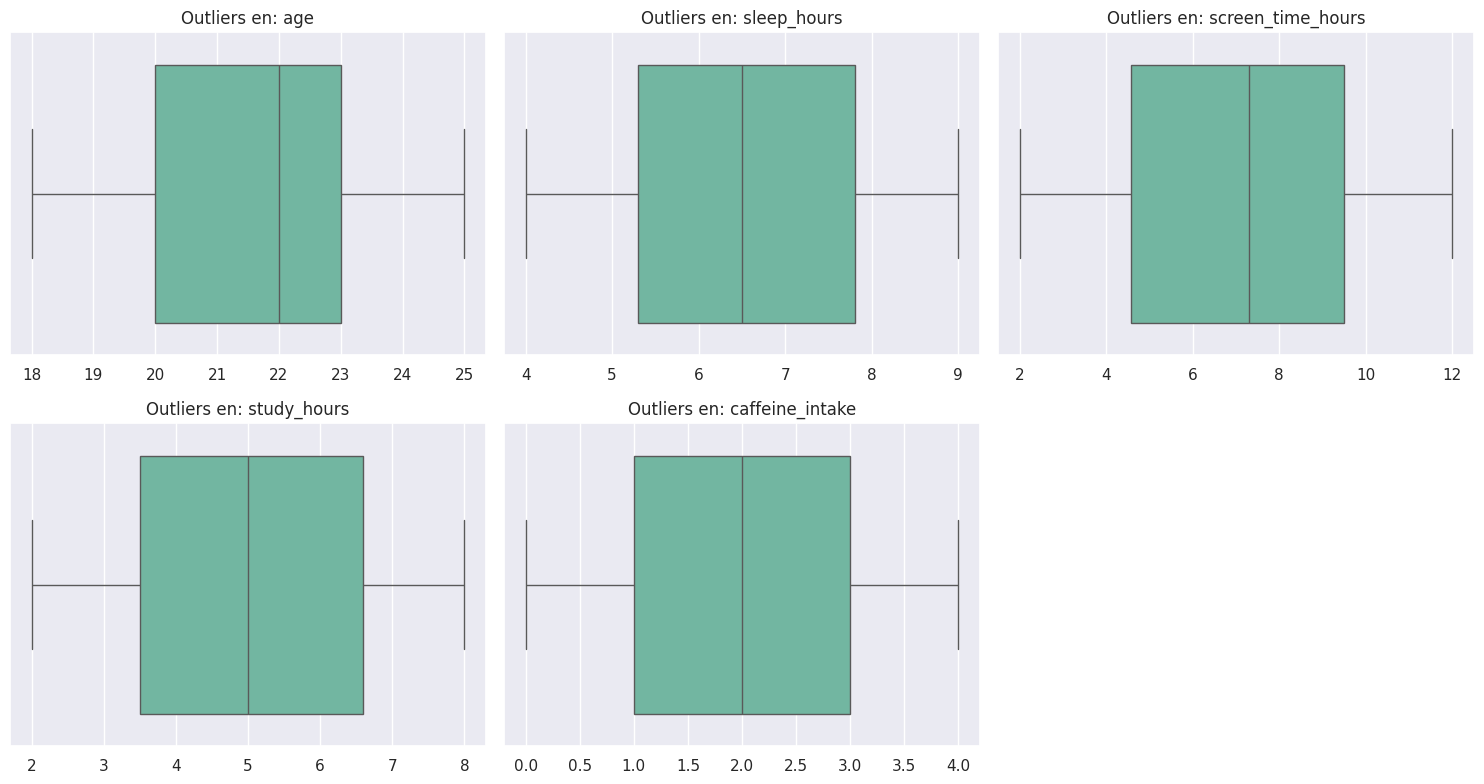

Conteo de outliers por columna:
Series([], dtype: int64)


In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


df_numeric = df.select_dtypes(include=['number'])


cols = df_numeric.columns
n_cols = 3
n_rows = (len(cols) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 4))
axes = axes.flatten()


for i, column in enumerate(cols):
    sns.boxplot(x=df_numeric[column], ax=axes[i], palette="Set2")
    axes[i].set_title(f'Outliers en: {column}', fontsize=12)
    axes[i].set_xlabel('')


for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


Q1 = df_numeric.quantile(0.25)
Q3 = df_numeric.quantile(0.75)
IQR = Q3 - Q1

outliers_count = ((df_numeric < (Q1 - 1.5 * IQR)) | (df_numeric > (Q3 + 1.5 * IQR))).sum()
print("Conteo de outliers por columna:")
print(outliers_count[outliers_count > 0])

---
### Pie chart
---

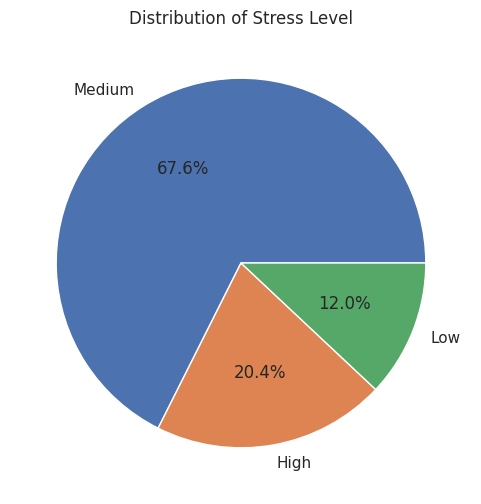

In [ ]:
stress_counts = df["stress_level"].value_counts()

plt.figure(figsize=(6,6))

plt.pie(
    stress_counts,
    labels=stress_counts.index,
    autopct="%1.1f%%"
)

plt.title("Distribution of Stress Level")

plt.show()

---
### Hist
---

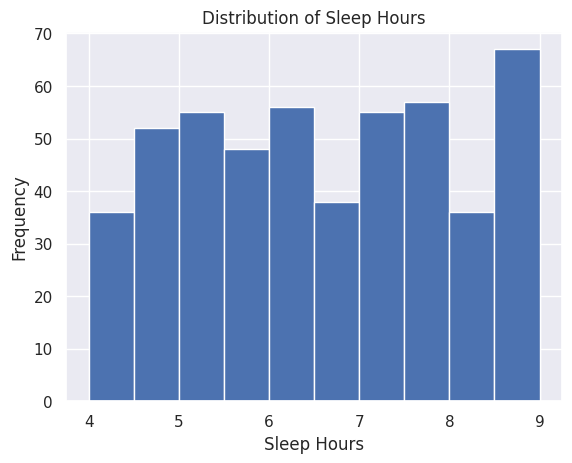

In [ ]:
plt.figure()

plt.hist(df["sleep_hours"], bins=10)

plt.title("Distribution of Sleep Hours")
plt.xlabel("Sleep Hours")
plt.ylabel("Frequency")

plt.show()

---
### Scatter plot
---

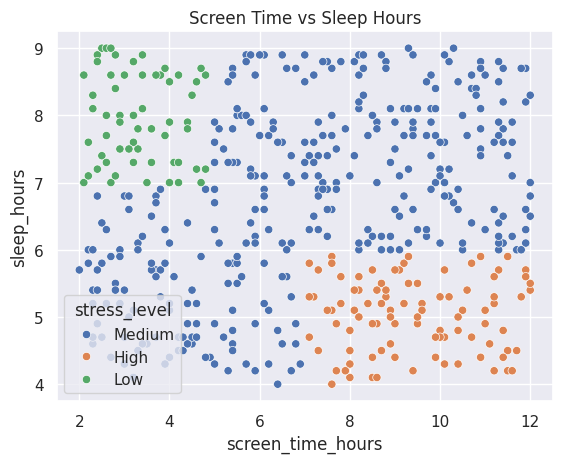

In [ ]:
import seaborn as sns

plt.figure()

sns.scatterplot(
    x="screen_time_hours",
    y="sleep_hours",
    hue="stress_level",
    data=df
)

plt.title("Screen Time vs Sleep Hours")

plt.show()

---
# Segunda pre-entrega
---

In [ ]:
df = pd.read_csv('https://drive.google.com/uc?id=1X4gLTWx5OwuxfhfyrYMz1-4VqP8IODri')
df = df.dropna()
df.head()

,student_id,age,gender,sleep_hours,screen_time_hours,stress_level,study_hours,physical_activity,caffeine_intake,academic_pressure
0,S001,22,Female,5.9,2.7,Medium,7.4,Yes,3,High
1,S002,25,Male,5.9,7.6,High,4.6,No,2,Low
2,S003,23,Male,8.0,3.2,Low,2.0,Yes,3,High
3,S004,22,Female,7.8,11.4,Medium,4.4,Yes,3,High
4,S005,20,Other,6.0,2.9,Medium,6.7,No,0,High


In [ ]:
#@title **code** Particionado 80/20
import pandas as pd
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

df = pd.read_csv('https://drive.google.com/uc?id=1X4gLTWx5OwuxfhfyrYMz1-4VqP8IODri')
df = df.drop(columns=["student_id"])
codes, uniques = pd.factorize(df["stress_level"])
df["stress_level"] = codes
y = df["stress_level"]
X = df.drop(columns=["stress_level"])
X['academic_pressure'] = pd.factorize(X['academic_pressure'])[0]
X['physical_activity'] = pd.factorize(X['physical_activity'])[0]
X['gender'] = pd.factorize(X['gender'])[0]

print(X.info())


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=21
)

final_results = {}

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   age                500 non-null    int64  
 1   gender             500 non-null    int64  
 2   sleep_hours        500 non-null    float64
 3   screen_time_hours  500 non-null    float64
 4   study_hours        500 non-null    float64
 5   physical_activity  500 non-null    int64  
 6   caffeine_intake    500 non-null    int64  
 7   academic_pressure  500 non-null    int64  
dtypes: float64(3), int64(5)
memory usage: 31.4 KB
None


In [ ]:
#@title **code** Decision Tree: tunning -> max:depth
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score
from sklearn.metrics import accuracy_score
from sklearn.model_selection import KFold
from sklearn.metrics import make_scorer

for depth in range(2, 11):
    model = DecisionTreeClassifier(max_depth=depth, random_state=21)
    model.fit(X_train, y_train)

    train_acc = accuracy_score(y_train, model.predict(X_train))
    test_acc = accuracy_score(y_test, model.predict(X_test))

    print(f"Depth {depth} -> Train: {train_acc:.3f} | Test: {test_acc:.3f}")

est = DecisionTreeClassifier(max_depth=3, random_state=21)
est.fit(X_train, y_train)
acc = accuracy_score(est.predict(X_test), y_test)
print("Accuracy score: ", acc)
final_results["Decision Tree"] = acc
print()

s = cross_val_score(est, X, y, cv=KFold(10, shuffle=True), scoring=make_scorer(accuracy_score))
print("accuracy %.3f (+/- %.5f)"%(np.mean(s), np.std(s)))
print()

#/////////////// predict
nuevo = [[22, 0, 7.0, 5.0, 6.0, 1, 2, 1]]
pred = est.predict(nuevo)
label = uniques[pred[0]]
print("Stress Level : ",label)

Depth 2 -> Train: 0.963 | Test: 0.940
Depth 3 -> Train: 1.000 | Test: 1.000
Depth 4 -> Train: 1.000 | Test: 1.000
Depth 5 -> Train: 1.000 | Test: 1.000
Depth 6 -> Train: 1.000 | Test: 1.000
Depth 7 -> Train: 1.000 | Test: 1.000
Depth 8 -> Train: 1.000 | Test: 1.000
Depth 9 -> Train: 1.000 | Test: 1.000
Depth 10 -> Train: 1.000 | Test: 1.000
Accuracy score:  1.0

accuracy 0.992 (+/- 0.02400)

Stress Level :  Medium


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


In [ ]:
#@title **code** Random Forest
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
from sklearn.metrics import accuracy_score
from sklearn.model_selection import KFold
from sklearn.metrics import make_scorer


for n in range(2, 11):
    model = RandomForestClassifier(n_estimators=n, random_state=21)
    model.fit(X_train, y_train)

    train_acc = accuracy_score(y_train, model.predict(X_train))
    test_acc = accuracy_score(y_test, model.predict(X_test))

    print(f"n_estimators={n} -> Train: {train_acc:.3f} | Test: {test_acc:.3f}")

est = RandomForestClassifier(n_estimators=10, random_state=21)
est.fit(X_train, y_train)
acc = accuracy_score(est.predict(X_test), y_test)
final_results["Random Forest"] = acc
print("Accuracy score: ",acc)

s = cross_val_score(est, X, y, cv=KFold(10, shuffle=True), scoring=make_scorer(accuracy_score))
print("accuracy %.3f (+/- %.5f)"%(np.mean(s), np.std(s)))
print()

#/////////////// predict
nuevo = [[22, 0, 7.0, 5.0, 6.0, 1, 2, 1]]
pred = est.predict(nuevo)
label = uniques[pred[0]]
print("Stress Level : ",label)

n_estimators=2 -> Train: 0.917 | Test: 0.810
n_estimators=3 -> Train: 0.988 | Test: 0.920
n_estimators=4 -> Train: 0.980 | Test: 0.880
n_estimators=5 -> Train: 0.998 | Test: 0.920
n_estimators=6 -> Train: 0.998 | Test: 0.940
n_estimators=7 -> Train: 0.998 | Test: 0.970
n_estimators=8 -> Train: 0.998 | Test: 0.960
n_estimators=9 -> Train: 0.995 | Test: 0.990
n_estimators=10 -> Train: 0.998 | Test: 0.960
Accuracy score:  0.96
accuracy 0.966 (+/- 0.03800)

Stress Level :  Medium


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [ ]:
#@title **code** SVM classification
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

kernels = ["linear", "poly", "rbf"]
svm_results = {}

for k in kernels:
    model = SVC(kernel=k)
    model.fit(X_train_scaled, y_train)

    acc = accuracy_score(y_test, model.predict(X_test_scaled))
    svm_results[k] = acc
    print(f"Kernel={k} -> Accuracy score: {acc:.3f}")

#/////////////// predict
print()
nuevo = [[22, 0, 7.0, 5.0, 6.0, 1, 2, 1]]
pred = est.predict(nuevo)
label = uniques[pred[0]]
print("Stress Level : ",label)

Kernel=linear -> Accuracy score: 0.900
Kernel=poly -> Accuracy score: 0.880
Kernel=rbf -> Accuracy score: 0.950

Stress Level :  Medium


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [ ]:
#@title **code** cross validation for SVM
from sklearn.model_selection import StratifiedKFold, cross_val_score

import numpy as np

skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=21)

for k in ["linear", "poly", "rbf"]:
    model = SVC(kernel=k)
    scores = cross_val_score(model, X, y, cv=skf, scoring='accuracy')
    print(f"{k} -> {scores.mean():.3f} (+/- {scores.std():.3f})")

linear -> 0.886 (+/- 0.037)
poly -> 0.878 (+/- 0.063)
rbf -> 0.786 (+/- 0.041)


---
### Deep learning
---

In [ ]:
#@title **code** Load libs
import tensorflow as tf
from tensorflow import keras
print(tf.__version__)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print (X_train.shape, y_train.shape, X_test.shape, y_test.shape)

2.20.0
(400, 8) (400,) (100, 8) (100,)


In [ ]:
#@title **code**  To normalize and prepare data

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print('X_train shape:', X_train_scaled.shape)
print('Number of samples in X_train:', X_train_scaled.shape[0])
print('Number of samples in X_test:', X_test_scaled.shape[0])

X_train shape: (400, 8)
Number of samples in X_train: 400
Number of samples in X_test: 100


In [ ]:
#@title **code** Coding a DNN from Keras with 3 layers

model = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(X_train.shape[1],)),
    tf.keras.layers.Dense(64, activation=tf.nn.relu),
    tf.keras.layers.Dense(128, activation=tf.nn.relu),
    tf.keras.layers.Dense(128, activation=tf.nn.relu),
    tf.keras.layers.Dense(3, activation=tf.nn.softmax)
])

model.summary() #Imprime la informacion de las capas

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_4 (Flatten)             │ (None, 8)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 64)             │           576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_28 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 25,795 (100.76 KB)

 Trainable params: 25,795 (100.76 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
#@title **code** Training a DNN with 3 layers
from sklearn.preprocessing import LabelEncoder

model.compile(optimizer=tf.keras.optimizers.SGD(),  #AdamOptimizer(),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])
model.fit(X_train_scaled, y_train, epochs=100)

Epoch 1/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.2975 - loss: 1.1225  
Epoch 2/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5550 - loss: 1.0173 
Epoch 3/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6650 - loss: 0.9463 
Epoch 4/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6775 - loss: 0.8977 
Epoch 5/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6775 - loss: 0.8642 
Epoch 6/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6775 - loss: 0.8394 
Epoch 7/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6775 - loss: 0.8224 
Epoch 8/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6775 - loss: 0.8096 
Epoch 9/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6775 - loss: 0.7994
Epoch 10/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6775 - loss: 0.7915 
Epoch 11/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6775 - loss: 0.7843 
Epoch 12/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 

In [ ]:
dl_results = {}
loss, acc = model.evaluate(X_test_scaled, y_test, verbose=0)
dl_results["3 layers"] = acc

In [ ]:
del model

In [ ]:
#@title **code** Coding a DNN from Keras with 6 layers

model = tf.keras.Sequential([
    tf.keras.layers.Flatten( input_shape=(X_train.shape[1],)), #input
    tf.keras.layers.Dense(64, activation=tf.nn.relu), #1
    tf.keras.layers.Dense(64, activation=tf.nn.relu), #2
    tf.keras.layers.Dense(128, activation=tf.nn.relu), #3
    tf.keras.layers.Dense(128, activation=tf.nn.relu), #4
    tf.keras.layers.Dense(256, activation=tf.nn.relu), #5
    tf.keras.layers.Dense(256, activation=tf.nn.relu), #6
    tf.keras.layers.Dense(3, activation=tf.nn.softmax) #output
])

model.summary() #Imprime la informacion de las capas

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_5 (Flatten)             │ (None, 8)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_30 (Dense)                │ (None, 64)             │           576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_31 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_32 (Dense)                │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_33 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_34 (Dense)                │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_35 (Dense)                │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_36 (Dense)                │ (None, 3)              │           771 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 129,155 (504.51 KB)

 Trainable params: 129,155 (504.51 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
#@title **code** Training a DNN with 6 layers
from sklearn.preprocessing import LabelEncoder

model.compile(optimizer=tf.keras.optimizers.SGD(),  #AdamOptimizer(),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])
model.fit(X_train_scaled, y_train, epochs=100)

Epoch 1/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.6300 - loss: 1.0493  
Epoch 2/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6775 - loss: 0.9777 
Epoch 3/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6775 - loss: 0.9252 
Epoch 4/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6775 - loss: 0.8895 
Epoch 5/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6775 - loss: 0.8666 
Epoch 6/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6775 - loss: 0.8526 
Epoch 7/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6775 - loss: 0.8428 
Epoch 8/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6775 - loss: 0.8372 
Epoch 9/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6775 - loss: 0.8320 
Epoch 10/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6775 - loss: 0.8273 
Epoch 11/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6775 - loss: 0.8235 
Epoch 12/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step

In [ ]:
loss, acc = model.evaluate(X_test_scaled, y_test, verbose=0)
dl_results["6 layers"] = acc

In [ ]:
del model

In [ ]:
#@title **code** Coding a DNN from Keras with 10 layers

model = tf.keras.Sequential([
    tf.keras.layers.Flatten( input_shape=(X_train.shape[1],)), #input
    tf.keras.layers.Dense(128, activation=tf.nn.relu), #1
    tf.keras.layers.Dense(128, activation=tf.nn.relu), #2
    tf.keras.layers.Dense(128, activation=tf.nn.relu), #3
    tf.keras.layers.Dense(128, activation=tf.nn.relu), #4
    tf.keras.layers.Dense(128, activation=tf.nn.relu), #5
    tf.keras.layers.Dense(128, activation=tf.nn.relu), #6
    tf.keras.layers.Dense(128, activation=tf.nn.relu), #7
    tf.keras.layers.Dense(128, activation=tf.nn.relu), #8
    tf.keras.layers.Dense(128, activation=tf.nn.relu), #9
    tf.keras.layers.Dense(128, activation=tf.nn.relu), #10
    tf.keras.layers.Dense(3, activation=tf.nn.softmax) #output
])

model.summary() #Imprime la informacion de las capas

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_6 (Flatten)             │ (None, 8)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_37 (Dense)                │ (None, 128)            │         1,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_38 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_39 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_40 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_41 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_42 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_43 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_44 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_45 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_46 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_47 (Dense)                │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 150,147 (586.51 KB)

 Trainable params: 150,147 (586.51 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
#@title **code** Training a DNN with 10 layers
from sklearn.preprocessing import LabelEncoder

model.compile(optimizer=tf.keras.optimizers.SGD(),  #AdamOptimizer(),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])
model.fit(X_train_scaled, y_train, epochs=100)

Epoch 1/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.5650 - loss: 1.0777  
Epoch 2/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6775 - loss: 1.0269 
Epoch 3/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6775 - loss: 0.9871 
Epoch 4/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6775 - loss: 0.9547 
Epoch 5/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6775 - loss: 0.9284 
Epoch 6/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6775 - loss: 0.9074 
Epoch 7/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6775 - loss: 0.8912 
Epoch 8/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6775 - loss: 0.8787 
Epoch 9/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6775 - loss: 0.8687 
Epoch 10/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6775 - loss: 0.8610 
Epoch 11/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6775 - loss: 0.8554
Epoch 12/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 

In [ ]:
loss, acc = model.evaluate(X_test_scaled, y_test, verbose=0)
dl_results["10 layers"] = acc

---
## Graficas
---

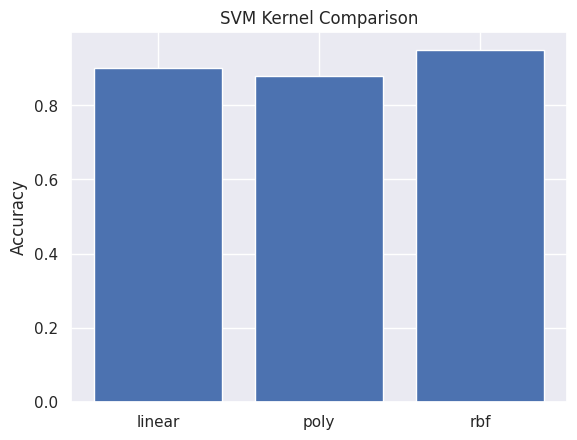

In [ ]:
#@title **code** SVM comparison
plt.figure()
plt.bar(svm_results.keys(), svm_results.values())

plt.title("SVM Kernel Comparison")
plt.ylabel("Accuracy")

plt.show()

final_results["SVM"] = svm_results["rbf"]

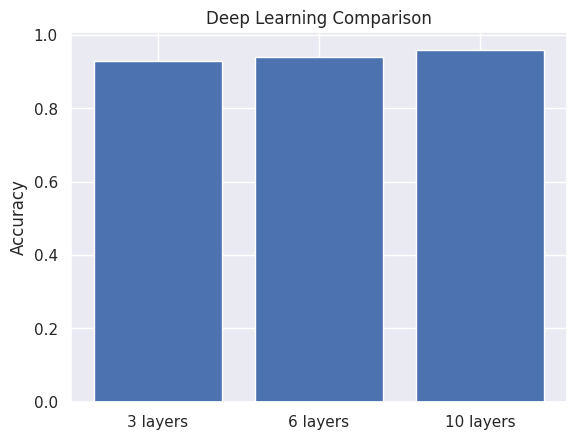

In [ ]:
#@title **code** DL comparison
plt.figure()
plt.bar(dl_results.keys(), dl_results.values())

plt.title("Deep Learning Comparison")
plt.ylabel("Accuracy")

plt.show()

# Mejor DL (el mejor de los 3)
best_dl = max(dl_results, key=dl_results.get)
final_results["Deep Learning"] = dl_results[best_dl]

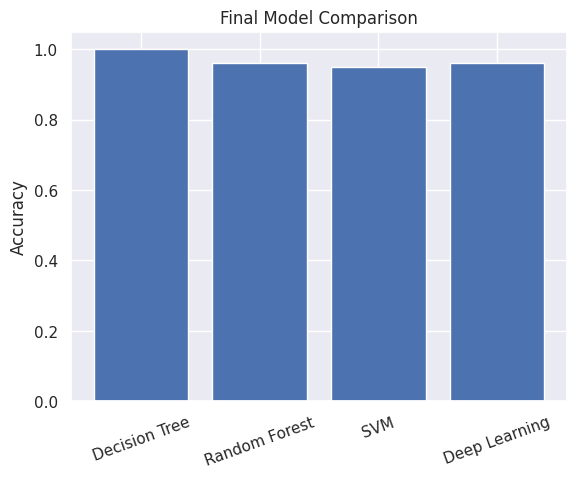

In [ ]:
#@title **code** Final comparison
plt.figure()
plt.bar(final_results.keys(), final_results.values())

plt.title("Final Model Comparison")
plt.ylabel("Accuracy")

plt.xticks(rotation=20)

plt.show()

---
# Tercera entrega
---

In [ ]:
#@title **code** Librerias
df = pd.read_csv('https://drive.google.com/uc?id=1X4gLTWx5OwuxfhfyrYMz1-4VqP8IODri')
df = df.drop(columns=["student_id"])
df.head()

,age,gender,sleep_hours,screen_time_hours,stress_level,study_hours,physical_activity,caffeine_intake,academic_pressure
0,22,Female,5.9,2.7,Medium,7.4,Yes,3,High
1,25,Male,5.9,7.6,High,4.6,No,2,Low
2,23,Male,8.0,3.2,Low,2.0,Yes,3,High
3,22,Female,7.8,11.4,Medium,4.4,Yes,3,High
4,20,Other,6.0,2.9,Medium,6.7,No,0,High


In [ ]:
#@title **code** Datos
import pandas as pd
import numpy as np

df['academic_pressure'] = pd.factorize(df['academic_pressure'])[0]
df['physical_activity'] = pd.factorize(df['physical_activity'])[0]
df['gender'] = pd.factorize(df['gender'])[0]
df["stress_level"] = pd.factorize(df["stress_level"])[0]
y = df["stress_level"]
X = df.drop(columns=["stress_level"])

In [ ]:
#@title **code** StandardScaler
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Shape escalado:", X_scaled.shape)

Shape escalado: (500, 8)


In [ ]:
#@title **code** Reducción dimensional PCA
from sklearn.decomposition import PCA
pca = PCA(n_components= 2, whiten=True)
X_pca = pca.fit_transform(X_scaled)

print("X PCA:", X_pca.shape)

X PCA: (500, 2)


In [ ]:
#@title **code** KMeans
from sklearn.cluster import KMeans

n_clusters = df["stress_level"].nunique()
kmeans = KMeans(n_clusters=n_clusters, random_state=21)
kmeans.fit(X_pca)

labels_kmeans = kmeans.labels_
print("Labels KMeans:")
print(labels_kmeans)

Labels KMeans:
[1 0 1 1 1 0 0 2 0 2 1 0 0 2 0 2 2 0 2 0 2 1 0 0 0 1 2 1 1 1 1 1 0 2 1 0 1
 2 0 0 1 2 2 0 0 1 2 1 1 0 2 0 1 1 2 2 0 0 1 0 1 1 2 1 1 2 0 1 1 0 1 2 2 0
 0 0 0 1 0 2 1 0 2 1 2 0 2 2 0 1 2 1 1 2 0 1 1 2 0 0 0 0 2 1 0 2 2 0 0 1 1
 0 1 0 0 0 0 0 2 0 1 2 0 2 2 0 0 2 0 1 1 1 2 0 1 2 0 1 1 1 0 0 0 1 2 2 0 2
 0 1 0 1 0 0 1 0 2 0 0 0 1 1 0 1 2 2 1 0 2 0 0 2 1 1 0 1 0 0 0 0 2 0 1 1 1
 1 0 1 1 1 0 0 1 2 1 1 0 1 1 1 1 2 0 1 1 0 1 1 0 0 0 1 0 0 2 0 1 0 1 2 1 2
 1 0 1 2 2 0 0 1 2 1 1 2 1 0 2 2 1 0 1 1 0 0 2 0 2 1 2 1 2 2 0 0 0 1 0 2 2
 0 2 2 2 2 2 1 0 2 0 2 1 2 2 0 2 0 2 2 2 2 1 0 1 2 2 2 0 0 1 2 1 1 0 0 1 0
 0 2 1 0 2 0 1 0 1 0 0 0 0 0 1 2 0 0 2 0 0 0 1 2 2 1 1 2 0 0 2 0 2 2 1 0 1
 2 1 1 1 0 2 1 2 2 0 1 0 2 0 0 1 2 1 0 1 1 0 1 1 0 2 2 2 1 0 0 1 2 2 2 0 0
 0 0 1 2 2 2 1 1 0 0 1 0 0 2 0 1 1 0 1 2 0 1 2 0 1 0 0 1 2 0 2 1 2 1 2 2 0
 0 1 2 0 0 1 1 2 2 0 1 2 0 0 0 0 1 2 0 1 1 0 0 1 2 2 0 2 0 0 1 2 1 2 0 2 0
 0 0 2 1 1 0 0 1 2 0 2 2 0 0 1 2 0 2 0 2 1 0 2 2 2 0 2 0 1 1 2 0 2 2 2 1 0
 1 0 1 1 2

In [ ]:
from sklearn.cluster import DBSCAN

eps_values = np.arange(0.1, 2.1, 0.1)
samples_values = range(3, 11)

resultados = []

for eps in eps_values:
    for min_samples in samples_values:

        dbscan_temp = DBSCAN(eps=eps, min_samples=min_samples)
        labels_temp = dbscan_temp.fit_predict(X_pca)

        clusters_dbscan = len(set(labels_temp)) - (1 if -1 in labels_temp else 0)
        ruido = np.mean(labels_temp == -1)

        score = abs(clusters_dbscan - n_clusters) + ruido

        resultados.append([
            eps,
            min_samples,
            clusters_dbscan,
            ruido,
            score
        ])

resultados_dbscan = pd.DataFrame(
    resultados,
    columns=["eps", "min_samples", "clusters", "ruido", "score"]
)

resultados_dbscan = resultados_dbscan.sort_values(["score", "ruido"])

print("Mejores combinaciones para DBSCAN:")
print(resultados_dbscan.head(10))

best_eps = resultados_dbscan.iloc[0]["eps"]
best_min_samples = int(resultados_dbscan.iloc[0]["min_samples"])

print("Mejor eps:", best_eps)
print("Mejor min_samples:", best_min_samples)

dbscan = DBSCAN(eps=best_eps, min_samples=best_min_samples)
labels_dbscan = dbscan.fit_predict(X_pca)

print("Labels DBSCAN:")
print(labels_dbscan)

print("Clusters encontrados por DBSCAN:")
print(len(set(labels_dbscan)) - (1 if -1 in labels_dbscan else 0))

print("Cantidad de ruido:")
print(np.sum(labels_dbscan == -1))

Mejores combinaciones para DBSCAN:
    eps  min_samples  clusters  ruido  score
17  0.3            4         3  0.056  0.056
18  0.3            5         3  0.070  0.070
19  0.3            6         3  0.086  0.086
22  0.3            9         3  0.228  0.228
16  0.3            3         2  0.054  1.054
20  0.3            7         4  0.126  1.126
21  0.3            8         4  0.182  1.182
3   0.1            6         2  0.962  1.962
48  0.7            3         1  0.000  2.000
49  0.7            4         1  0.000  2.000
Mejor eps: 0.30000000000000004
Mejor min_samples: 4
Labels DBSCAN:
[ 0  0  0  0  0  0  0  0  0  0  0  0  0  0  0 -1 -1  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0 -1  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0 -1  0  0  0  0  

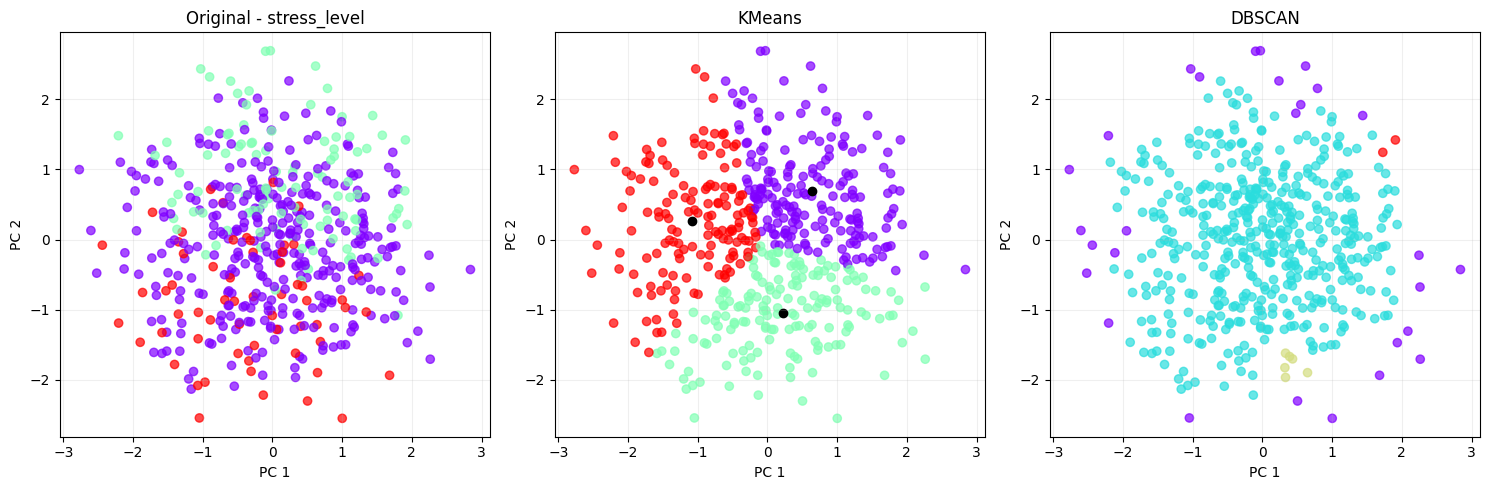

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(15, 5))

plt.subplot(131)
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap="rainbow", alpha=0.7)
plt.title("Original - stress_level")
plt.xlabel("PC 1")
plt.ylabel("PC 2")
plt.grid(alpha=0.2)

plt.subplot(132)
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels_kmeans, cmap="rainbow", alpha=0.7)
plt.scatter(
    kmeans.cluster_centers_[:, 0],
    kmeans.cluster_centers_[:, 1],
    color="black"
)
plt.title("KMeans")
plt.xlabel("PC 1")
plt.ylabel("PC 2")
plt.grid(alpha=0.2)

plt.subplot(133)
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels_dbscan, cmap="rainbow", alpha=0.7)
plt.title("DBSCAN")
plt.xlabel("PC 1")
plt.ylabel("PC 2")
plt.grid(alpha=0.2)

plt.tight_layout()
plt.show()